# Numerical Stability of Explicit and Implicit Methods for a Bounded Memristor ODE

This notebook implements the project described in `Lagramada-Villareal-Proposal.pdf`. It compares Explicit Euler, classical RK4, and Implicit Euler on the HP TiO2 memristor state equation.

The raw numerical states are kept unchanged so that boundary overshoot can be measured. A clipped copy is used only when producing physically meaningful current-voltage curves.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

FIGURE_DIR = os.path.join("..", "latex", "figures")
TABLE_DIR = os.path.join("..", "latex", "tables")
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

## Parameters

The physical constants below follow the standard HP TiO2 model scale. The drive frequency is set as a compact stress case: it is high enough to keep the simulation short, but low enough that boundary overshoot appears in the raw trajectories.

In [2]:
params = {
    "Ron": 100.0,
    "Roff": 16_000.0,
    "D": 10e-9,
    "mu_v": 1e-14,
    "V0": 1.0,
    "frequency_hz": 1.0e8,
    "w0_fraction": 0.5,
    "periods": 3,
}

params["omega"] = 2.0 * np.pi * params["frequency_hz"]
params["period"] = 1.0 / params["frequency_hz"]
params["w0"] = params["w0_fraction"] * params["D"]
params["t0"] = 0.0
params["tf"] = params["periods"] * params["period"]

steps_per_period = [400, 80, 20, 8]
step_cases = [(f"T/{spp}", params["period"] / spp, spp) for spp in steps_per_period]

pd.DataFrame([params]).T.rename(columns={0: "value"})

,value
Ron,1.000000e+02
Roff,1.600000e+04
D,1.000000e-08
mu_v,1.000000e-14
V0,1.000000e+00
frequency_hz,1.000000e+08
w0_fraction,5.000000e-01
periods,3.000000e+00
omega,6.283185e+08
period,1.000000e-08


## Model Functions

In [3]:
def voltage(t, p):
    return p["V0"] * np.sin(p["omega"] * t)


def memristance(w, p):
    return p["Ron"] * (w / p["D"]) + p["Roff"] * (1.0 - w / p["D"])


def current(t, w, p):
    return voltage(t, p) / memristance(w, p)


def state_rhs(t, w, p):
    numerator = p["mu_v"] * p["Ron"] * voltage(t, p)
    denominator = (p["D"] ** 2) * memristance(w, p)
    return numerator / denominator


def state_rhs_dw(t, w, p):
    m_prime = (p["Ron"] - p["Roff"]) / p["D"]
    coefficient = p["mu_v"] * p["Ron"] * voltage(t, p) / (p["D"] ** 2)
    return -coefficient * m_prime / (memristance(w, p) ** 2)


def clip_state(w, p):
    return np.clip(w, 0.0, p["D"])

## Solvers

In [4]:
def time_grid(t0, tf, h):
    n_steps = int(np.ceil((tf - t0) / h))
    return np.linspace(t0, tf, n_steps + 1)


def explicit_euler(p, h):
    t = time_grid(p["t0"], p["tf"], h)
    w = np.empty_like(t)
    w[0] = p["w0"]
    for n in range(len(t) - 1):
        dt = t[n + 1] - t[n]
        w[n + 1] = w[n] + dt * state_rhs(t[n], w[n], p)
    return t, w


def rk4(p, h):
    t = time_grid(p["t0"], p["tf"], h)
    w = np.empty_like(t)
    w[0] = p["w0"]
    for n in range(len(t) - 1):
        dt = t[n + 1] - t[n]
        k1 = state_rhs(t[n], w[n], p)
        k2 = state_rhs(t[n] + 0.5 * dt, w[n] + 0.5 * dt * k1, p)
        k3 = state_rhs(t[n] + 0.5 * dt, w[n] + 0.5 * dt * k2, p)
        k4 = state_rhs(t[n] + dt, w[n] + dt * k3, p)
        w[n + 1] = w[n] + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    return t, w


def implicit_quadratic_fallback(w_previous, t_next, dt, p, target):
    a = p["Roff"]
    b = (p["Ron"] - p["Roff"]) / p["D"]
    c = p["mu_v"] * p["Ron"] * voltage(t_next, p) / (p["D"] ** 2)
    coefficients = [b, a - b * w_previous, -a * w_previous - dt * c]
    roots = np.roots(coefficients)
    real_roots = roots[np.isclose(roots.imag, 0.0, atol=1e-18)].real
    if len(real_roots) == 0:
        return target
    return real_roots[np.argmin(np.abs(real_roots - target))]


def implicit_euler(p, h, tol=1e-13, max_iter=30):
    t = time_grid(p["t0"], p["tf"], h)
    w = np.empty_like(t)
    iterations = np.zeros(len(t) - 1, dtype=int)
    used_fallback = np.zeros(len(t) - 1, dtype=bool)
    w[0] = p["w0"]

    for n in range(len(t) - 1):
        dt = t[n + 1] - t[n]
        t_next = t[n + 1]
        guess = w[n] + dt * state_rhs(t[n], w[n], p)

        for iteration in range(1, max_iter + 1):
            residual = guess - w[n] - dt * state_rhs(t_next, guess, p)
            derivative = 1.0 - dt * state_rhs_dw(t_next, guess, p)
            if (not np.isfinite(residual)) or (not np.isfinite(derivative)) or abs(derivative) < 1e-30:
                used_fallback[n] = True
                break
            correction = residual / derivative
            guess -= correction
            if abs(correction) <= tol * max(1.0, abs(guess)):
                break
        else:
            used_fallback[n] = True

        if used_fallback[n]:
            guess = implicit_quadratic_fallback(w[n], t_next, dt, p, guess)

        iterations[n] = iteration
        w[n + 1] = guess

    return t, w, iterations, used_fallback

## Run Experiments

In [5]:
solver_specs = [
    ("Explicit Euler", explicit_euler),
    ("RK4", rk4),
    ("Implicit Euler", implicit_euler),
]

TIMING_REPEATS = 7

results = []
for step_label, h_requested, spp in step_cases:
    for method_name, solver in solver_specs:
        timed_outputs = []
        runtimes = []
        for _ in range(TIMING_REPEATS):
            start = time.perf_counter()
            output = solver(params.copy(), h_requested)
            runtimes.append(time.perf_counter() - start)
            timed_outputs.append(output)

        output = timed_outputs[0]
        t, w_raw = output[0], output[1]
        actual_h = np.diff(t).mean()
        w_clipped = clip_state(w_raw, params)
        record = {
            "method": method_name,
            "step_label": step_label,
            "steps_per_period": spp,
            "h": actual_h,
            "n_steps": len(t) - 1,
            "runtime_seconds": runtimes[0],
            "runtime_median_seconds": float(np.median(runtimes)),
            "runtime_min_seconds": float(np.min(runtimes)),
            "runtime_repeats": TIMING_REPEATS,
            "t": t,
            "w_raw": w_raw,
            "w_clipped": w_clipped,
            "v": voltage(t, params),
            "i_clipped": current(t, w_clipped, params),
        }
        record["runtime_per_step_seconds"] = record["runtime_median_seconds"] / record["n_steps"]
        record["runtime_per_period_seconds"] = record["runtime_median_seconds"] / params["periods"]
        if method_name == "Implicit Euler":
            record["newton_iterations"] = output[2]
            record["implicit_fallback"] = output[3]
        results.append(record)

len(results)


12

## Summary Tables

In [6]:
summary_rows = []
final_rows = []
runtime_rows = []

for result in results:
    w = result["w_raw"]
    below = np.maximum(0.0, -w)
    above = np.maximum(0.0, w - params["D"])
    out_of_bounds = (w < 0.0) | (w > params["D"])
    summary_rows.append({
        "method": result["method"],
        "step_label": result["step_label"],
        "h_seconds": result["h"],
        "min_w_over_D": np.min(w) / params["D"],
        "max_w_over_D": np.max(w) / params["D"],
        "max_below_0_over_D": np.max(below) / params["D"],
        "max_above_D_over_D": np.max(above) / params["D"],
        "out_of_bounds_count": int(np.sum(out_of_bounds)),
        "out_of_bounds_percent": 100.0 * np.mean(out_of_bounds),
    })

    final_record = {
        "method": result["method"],
        "step_label": result["step_label"],
        "final_raw_w_over_D": w[-1] / params["D"],
        "final_clipped_w_over_D": result["w_clipped"][-1] / params["D"],
    }
    if result["method"] == "Implicit Euler":
        final_record["max_newton_iterations"] = int(np.max(result["newton_iterations"]))
        final_record["implicit_fallbacks"] = int(np.sum(result["implicit_fallback"]))
    final_rows.append(final_record)

    runtime_rows.append({
        "method": result["method"],
        "step_label": result["step_label"],
        "h_seconds": result["h"],
        "n_steps": result["n_steps"],
        "runtime_repeats": result["runtime_repeats"],
        "runtime_seconds_first_run": result["runtime_seconds"],
        "runtime_median_seconds": result["runtime_median_seconds"],
        "runtime_min_seconds": result["runtime_min_seconds"],
        "runtime_per_step_seconds": result["runtime_per_step_seconds"],
        "runtime_per_period_seconds": result["runtime_per_period_seconds"],
    })

overshoot_summary = pd.DataFrame(summary_rows)
final_state_summary = pd.DataFrame(final_rows)
runtime_summary = pd.DataFrame(runtime_rows)

overshoot_summary.to_csv(os.path.join(TABLE_DIR, "overshoot_summary.csv"), index=False)
final_state_summary.to_csv(os.path.join(TABLE_DIR, "final_state_summary.csv"), index=False)
runtime_summary.to_csv(os.path.join(TABLE_DIR, "runtime_summary.csv"), index=False)

overshoot_summary


,method,step_label,h_seconds,min_w_over_D,max_w_over_D,max_below_0_over_D,max_above_D_over_D,out_of_bounds_count,out_of_bounds_percent
0,Explicit Euler,T/400,2.497918e-11,0.500000,1.679392,0.0,0.679392,1070,89.018303
1,RK4,T/400,2.497918e-11,0.358098,1.115702,0.0,0.115702,8,0.665557
2,Implicit Euler,T/400,2.497918e-11,0.500000,2.611846,0.0,1.611846,1085,90.266223
3,Explicit Euler,T/80,1.244813e-10,0.340026,1.101095,0.0,0.101095,2,0.826446
4,RK4,T/80,1.244813e-10,0.500000,1.693632,0.0,0.693632,210,86.776860
5,Implicit Euler,T/80,1.244813e-10,0.500000,1.729488,0.0,0.729488,218,90.082645
6,Explicit Euler,T/20,4.918033e-10,0.279408,1.180415,0.0,0.180415,2,3.225806
7,RK4,T/20,4.918033e-10,0.500000,1.643625,0.0,0.643625,55,88.709677
8,Implicit Euler,T/20,4.918033e-10,0.500000,3.671608,0.0,2.671608,56,90.322581
9,Explicit Euler,T/8,1.200000e-09,0.188199,1.055229,0.0,0.055229,1,3.846154


In [7]:
final_state_summary

,method,step_label,final_raw_w_over_D,final_clipped_w_over_D,max_newton_iterations,implicit_fallbacks
0,Explicit Euler,T/400,1.679392,1.000000,NaN,NaN
1,RK4,T/400,0.358098,0.358098,NaN,NaN
2,Implicit Euler,T/400,2.611715,1.000000,30.0,2.0
3,Explicit Euler,T/80,0.340026,0.340026,NaN,NaN
4,RK4,T/80,1.693632,1.000000,NaN,NaN
5,Implicit Euler,T/80,1.729488,1.000000,30.0,10.0
6,Explicit Euler,T/20,0.279408,0.279408,NaN,NaN
7,RK4,T/20,1.643625,1.000000,NaN,NaN
8,Implicit Euler,T/20,3.670680,1.000000,30.0,2.0
9,Explicit Euler,T/8,0.188199,0.188199,NaN,NaN


## Runtime Summary

Runtime is measured with `time.perf_counter()` over repeated solver calls. The median is reported to reduce one-off notebook noise. These timings should be treated as relative computational-cost indicators, not hardware-independent benchmarks.

In [8]:
runtime_summary

,method,step_label,h_seconds,n_steps,runtime_repeats,runtime_seconds_first_run,runtime_median_seconds,runtime_min_seconds,runtime_per_step_seconds,runtime_per_period_seconds
0,Explicit Euler,T/400,2.497918e-11,1201,7,0.001125,0.001130,0.001058,9.411699e-07,0.000377
1,RK4,T/400,2.497918e-11,1201,7,0.005211,0.004148,0.003992,3.453930e-06,0.001383
2,Implicit Euler,T/400,2.497918e-11,1201,7,0.008777,0.007399,0.005865,6.160692e-06,0.002466
3,Explicit Euler,T/80,1.244813e-10,241,7,0.000266,0.000268,0.000256,1.110651e-06,0.000089
4,RK4,T/80,1.244813e-10,241,7,0.000978,0.000884,0.000691,3.667519e-06,0.000295
5,Implicit Euler,T/80,1.244813e-10,241,7,0.002817,0.002760,0.002201,1.145151e-05,0.000920
6,Explicit Euler,T/20,4.918033e-10,61,7,0.000053,0.000048,0.000045,7.900000e-07,0.000016
7,RK4,T/20,4.918033e-10,61,7,0.000170,0.000173,0.000160,2.837180e-06,0.000058
8,Implicit Euler,T/20,4.918033e-10,61,7,0.000482,0.000490,0.000477,8.033066e-06,0.000163
9,Explicit Euler,T/8,1.200000e-09,25,7,0.000024,0.000021,0.000020,8.510000e-07,0.000007


## Runtime Plot

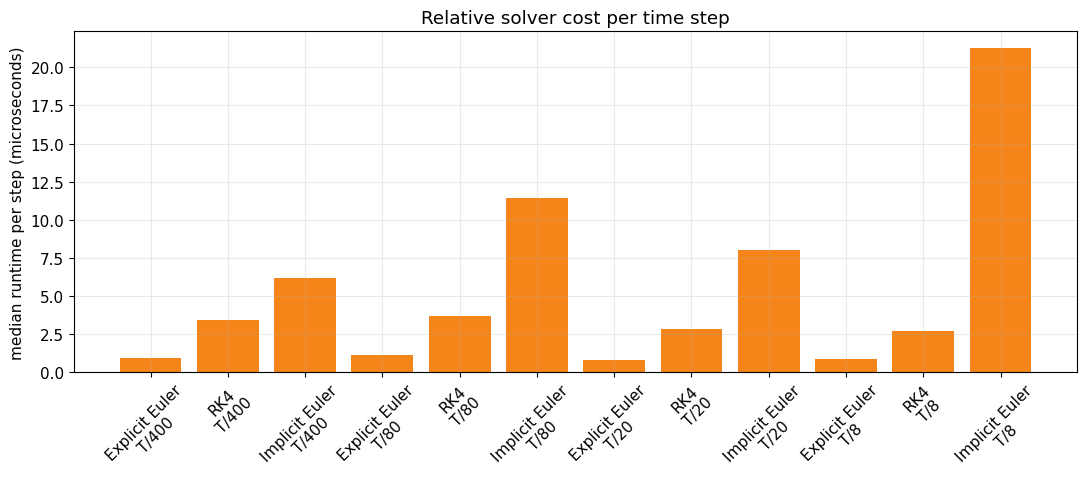

In [9]:
runtime_plot_table = runtime_summary.copy()
runtime_plot_table["case"] = runtime_plot_table["method"] + "\n" + runtime_plot_table["step_label"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(runtime_plot_table["case"], runtime_plot_table["runtime_per_step_seconds"] * 1e6, color="#F58518")
ax.set_ylabel("median runtime per step (microseconds)")
ax.set_title("Relative solver cost per time step")
ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "runtime_per_step.png"), dpi=180)
plt.show()

## State Trajectories

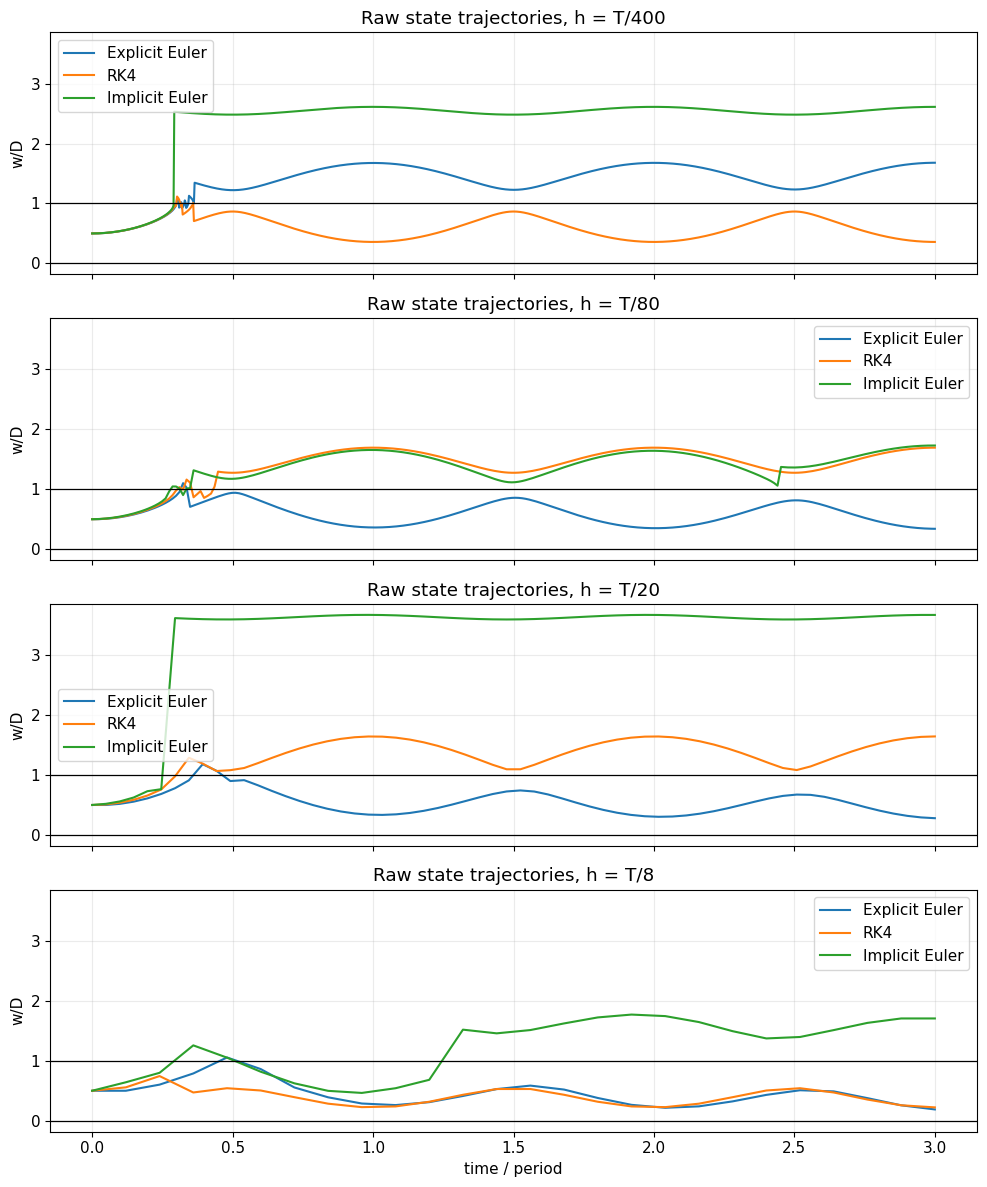

In [10]:
fig, axes = plt.subplots(len(step_cases), 1, figsize=(10, 12), sharex=True, sharey=True)
if len(step_cases) == 1:
    axes = [axes]

for ax, (step_label, _, _) in zip(axes, step_cases):
    for result in results:
        if result["step_label"] != step_label:
            continue
        ax.plot(result["t"] / params["period"], result["w_raw"] / params["D"], label=result["method"])
    ax.axhline(0.0, color="black", linewidth=0.9)
    ax.axhline(1.0, color="black", linewidth=0.9)
    ax.set_ylabel("w/D")
    ax.set_title(f"Raw state trajectories, h = {step_label}")
    ax.legend(loc="best")

axes[-1].set_xlabel("time / period")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "state_trajectories.png"), dpi=180)
plt.show()

## Boundary Violations

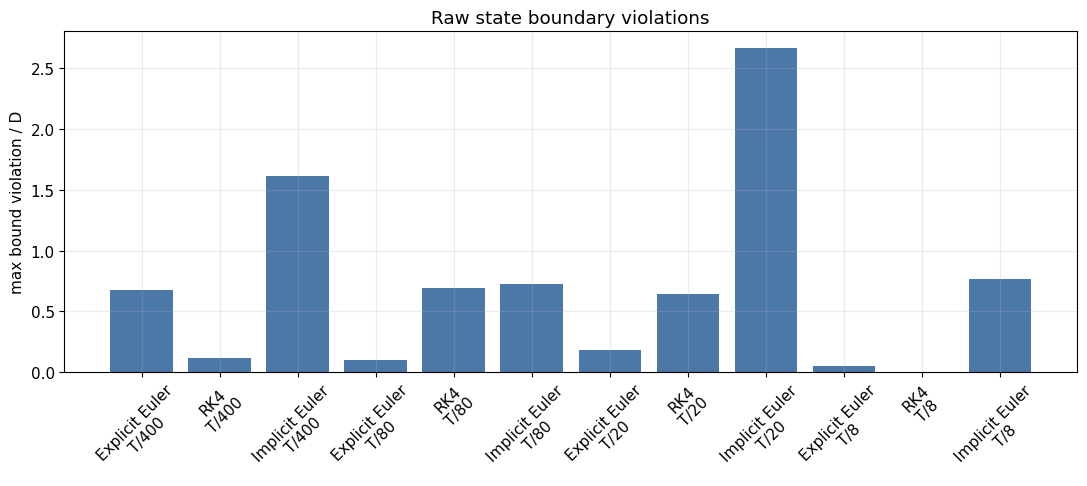

In [11]:
plot_table = overshoot_summary.copy()
plot_table["total_violation_over_D"] = plot_table["max_below_0_over_D"] + plot_table["max_above_D_over_D"]
plot_table["case"] = plot_table["method"] + "\n" + plot_table["step_label"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(plot_table["case"], plot_table["total_violation_over_D"], color="#4C78A8")
ax.set_ylabel("max bound violation / D")
ax.set_title("Raw state boundary violations")
ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "bound_violations.png"), dpi=180)
plt.show()

## V-I Hysteresis Loops

These curves use clipped state values so that the current is evaluated with physically valid memristance.

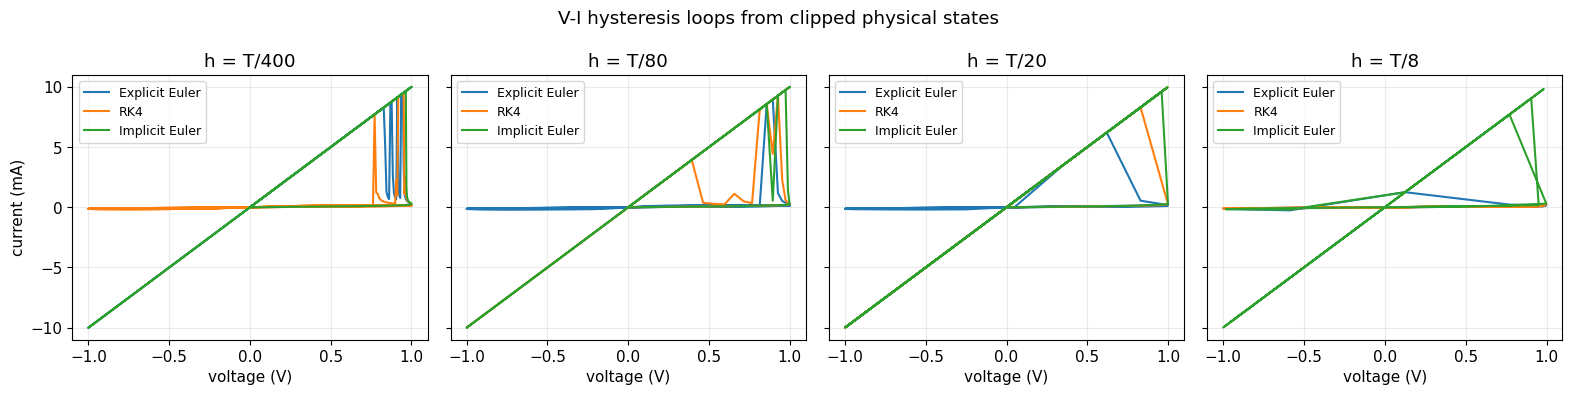

In [12]:
fig, axes = plt.subplots(1, len(step_cases), figsize=(16, 4), sharey=True)
if len(step_cases) == 1:
    axes = [axes]

for ax, (step_label, _, _) in zip(axes, step_cases):
    for result in results:
        if result["step_label"] != step_label:
            continue
        ax.plot(result["v"], result["i_clipped"] * 1e3, label=result["method"])
    ax.set_title(f"h = {step_label}")
    ax.set_xlabel("voltage (V)")
    ax.legend(loc="best", fontsize=9)

axes[0].set_ylabel("current (mA)")
fig.suptitle("V-I hysteresis loops from clipped physical states")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "hysteresis_loops.png"), dpi=180)
plt.show()

## Interpretation

The fine-grid runs provide the baseline behavior. Coarser grids are included to make step-size sensitivity visible. Explicit Euler is expected to show the strongest dependence on step size. RK4 usually tracks the smooth solution better at a comparable step size, but it remains explicit. Implicit Euler is first-order, but its future-time update tends to damp unstable growth more strongly than Explicit Euler.